<a href="https://colab.research.google.com/github/sugamkumar-2809/CODTECH-Project-4-House-Price-Prediction/blob/main/Project4_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. SetUp


In [2]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [5]:
#configuration
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize":8,
    "ytick.labelsize":8
})

RANDOM_STATE =42
CSV_PATH="House Price Prediction Dataset.csv" #UPDATE PATH FOR A DIFFERENT DATASET
TARGET_COL="Price" #target column name

2.Load Data

In [6]:
df=pd.read_csv(CSV_PATH)

In [7]:
print("DataFrame shape:", df.shape)

DataFrame shape: (2000, 10)


In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


3.Exploratory Data Analysis(EDA)

In [8]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [9]:
#basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [10]:
num_cols=df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols=df.select_dtypes(include=["object"]).columns.tolist()

In [11]:
print("Target column:",TARGET_COL)
print("Numerical columns:",num_cols)
print("Categorical columns:",cat_cols)

Target column: Price
Numerical columns: ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
Categorical columns: ['Location', 'Condition', 'Garage']


In [12]:
#missing values analysis
print("\nMissing values analysis:")
print(df.isnull().sum())


Missing values analysis:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [13]:
# check presence of encoded missing values
for col in df.columns:
  print(df[col].value_counts().head(20))

Id
1984    1
1983    1
1982    1
1981    1
1980    1
1979    1
1978    1
1977    1
1976    1
1975    1
1974    1
1973    1
1972    1
1971    1
1970    1
1969    1
32      1
31      1
30      1
29      1
Name: count, dtype: int64
Area
4219    5
1752    4
4646    4
1516    4
1743    4
3691    4
1074    3
3274    3
2000    3
1213    3
4607    3
3349    3
1228    3
3572    3
3279    3
3438    3
509     3
1454    3
3617    3
2469    3
Name: count, dtype: int64
Bedrooms
1    418
3    406
4    405
5    403
2    368
Name: count, dtype: int64
Bathrooms
3    524
4    521
2    494
1    461
Name: count, dtype: int64
Floors
2    691
1    661
3    648
Name: count, dtype: int64
YearBuilt
2005    27
2002    26
1901    25
1981    24
2000    23
1957    23
1938    23
1932    22
1930    22
1924    22
2013    21
1925    21
2014    21
1970    21
2017    21
1911    21
1910    20
2003    20
1928    20
1976    20
Name: count, dtype: int64
Location
Downtown    558
Urban       485
Suburban    483
Rural       474

In [14]:
#duplicates
duplicate_mark = df.duplicated()
num_duplicates = duplicate_mark.sum()
print("Number of duplicate rows: ", num_duplicates)

Number of duplicate rows:  0


In [15]:
#descriptive stat
df[num_cols].describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,1000.500,2786.209,3.003,2.553,1.994,1961.446,537676.855
std,577.495,1295.147,1.425,1.109,0.809,35.927,276428.846
min,1.000,501.000,1.000,1.000,1.000,1900.000,50005.000
25%,500.750,1653.000,2.000,2.000,1.000,1930.000,300098.000
50%,1000.500,2833.000,3.000,3.000,2.000,1961.000,539254.000
75%,1500.250,3887.500,4.000,4.000,3.000,1993.000,780086.000
max,2000.000,4999.000,5.000,4.000,3.000,2023.000,999656.000


In [16]:
#descriptive stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2000.000,1000.500,577.495,1.000,500.750,1000.500,1500.250,2000.000
Area,2000.000,2786.209,1295.147,501.000,1653.000,2833.000,3887.500,4999.000
Bedrooms,2000.000,3.003,1.425,1.000,2.000,3.000,4.000,5.000
Bathrooms,2000.000,2.553,1.109,1.000,2.000,3.000,4.000,4.000
Floors,2000.000,1.994,0.809,1.000,1.000,2.000,3.000,3.000
YearBuilt,2000.000,1961.446,35.927,1900.000,1930.000,1961.000,1993.000,2023.000
Price,2000.000,537676.855,276428.846,50005.000,300098.000,539254.000,780086.000,999656.000


Data Visualization

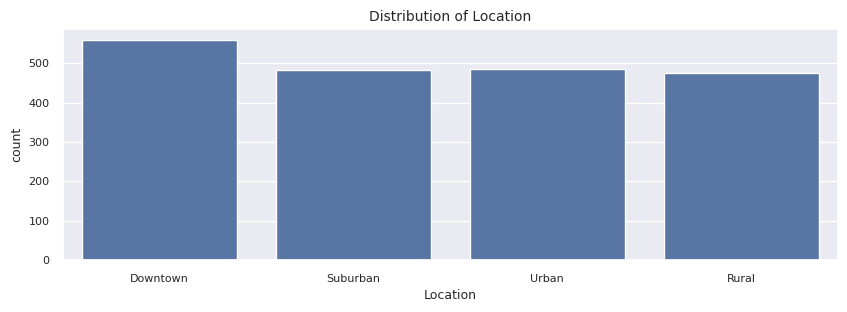

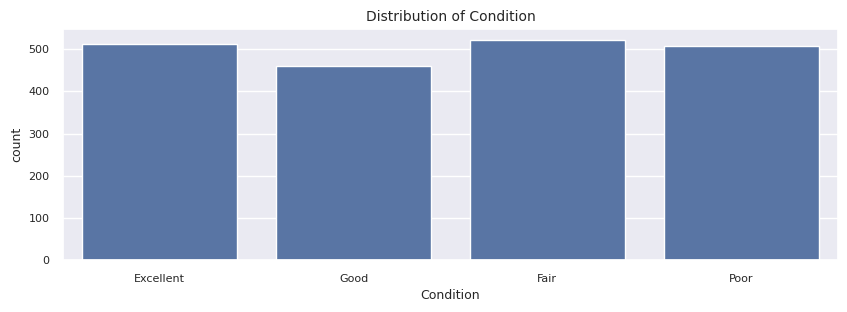

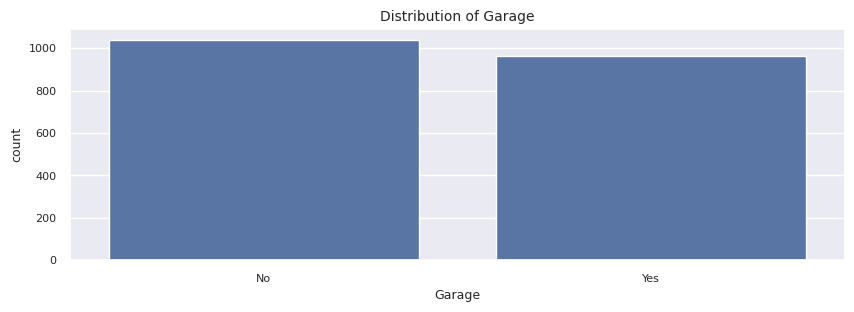

In [17]:
#countplot for categorical columns
for col in cat_cols:
  plt.figure(figsize=(10,3))
  sns.countplot(x=col, data=df)
  plt.title(f"Distribution of {col}")
  plt.show()

In [18]:
for col in cat_cols:
  print(df[col].value_counts())

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64
Garage
No     1038
Yes     962
Name: count, dtype: int64


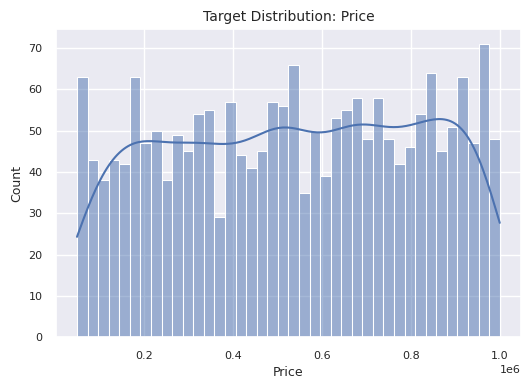

In [19]:
#target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Price"], bins=40,kde=True)
plt.title("Target Distribution: Price")
plt.xlabel("Price")
plt.show()

In [20]:
df[TARGET_COL].value_counts()

,count
Price,
959222,2
386433,1
77597,1
530545,1
419170,1
...,...
55310,1
100272,1
523267,1


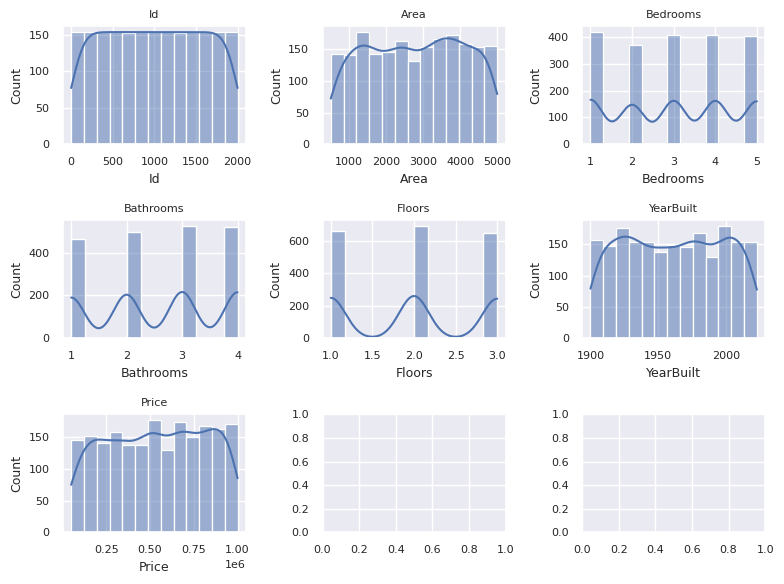

In [21]:
#histogram plot - distribution
fig, axes = plt.subplots(3,3, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.histplot(df[col], kde=True, ax=axes[i])
  axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

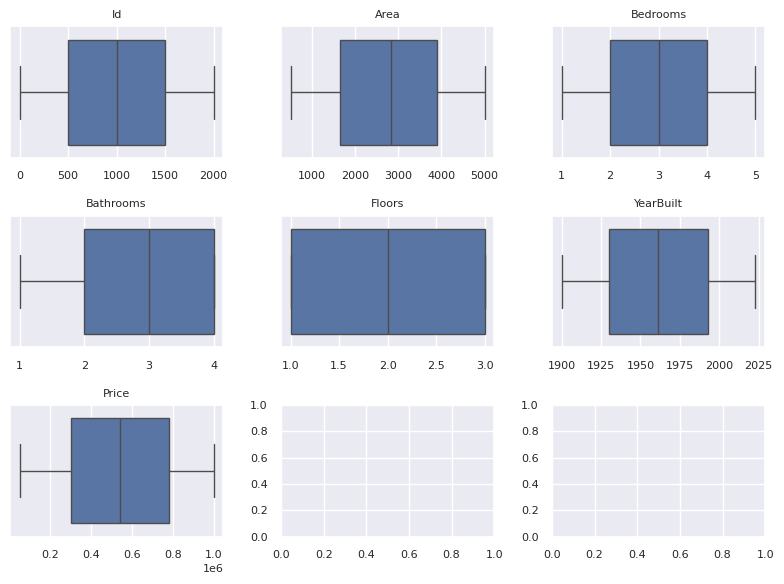

In [22]:
#outliers analysis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

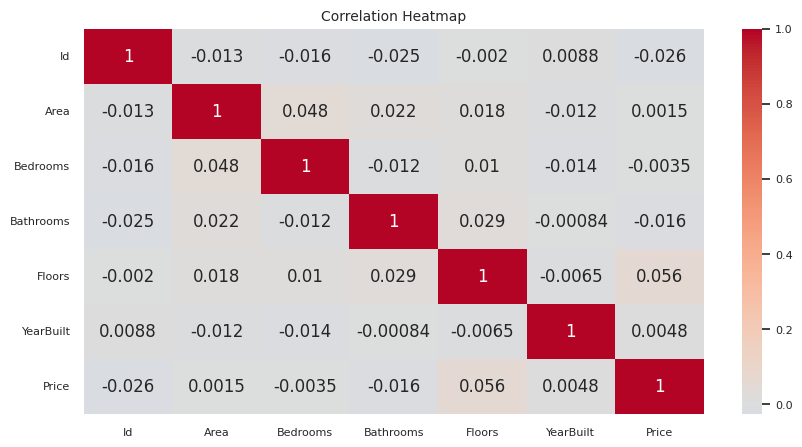

In [23]:
#identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10,5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
#Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
Price        1.000
Floors       0.056
YearBuilt    0.005
Area         0.002
Bedrooms    -0.003
Bathrooms   -0.016
Id          -0.026
Name: Price, dtype: float64


4. Data Preprocessing

In [25]:
#separate features and target
X=df.drop(columns=[TARGET_COL])
y=df[TARGET_COL]

In [ ]:
X.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,1,1360,5,4,3,1970,Downtown,Excellent,No
1,2,4272,5,4,3,1958,Downtown,Excellent,No
2,3,3592,2,2,3,1938,Downtown,Good,No
3,4,966,4,2,2,1902,Suburban,Fair,Yes
4,5,4926,1,4,2,1975,Downtown,Fair,Yes


In [26]:
y.head()

,Price
0,149919
1,424998
2,266746
3,244020
4,636056


In [27]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [28]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1600, 9)
Test shape: (400, 9)


Preprocessing Pipeline

In [29]:
numerical_features=X_train.select_dtypes(include=[np.number])
numerical_features

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt
968,969,4483,4,4,3,1933
240,241,1062,3,3,1,1970
819,820,1422,3,4,1,1993
692,693,2658,2,3,1,1972
420,421,3286,2,4,1,1981
...,...,...,...,...,...,...
1130,1131,3483,5,3,3,1931
1294,1295,1747,3,3,2,1941
860,861,1484,2,3,3,1973
1459,1460,3456,5,4,1,1955


In [30]:
numerical_features=X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features=X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical_features:", numerical_features)
print("Categorical_features:", categorical_features)

#numerical features - preprocessing steps
numeric_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#numerical features - preprocessing steps
categorical_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#preprocessing pipeline
preprocess=ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical_features: ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
Categorical_features: ['Location', 'Condition', 'Garage']


In [31]:
X_train

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
968,969,4483,4,4,3,1933,Urban,Excellent,No
240,241,1062,3,3,1,1970,Downtown,Good,No
819,820,1422,3,4,1,1993,Urban,Good,Yes
692,693,2658,2,3,1,1972,Rural,Poor,Yes
420,421,3286,2,4,1,1981,Rural,Excellent,Yes
...,...,...,...,...,...,...,...,...,...
1130,1131,3483,5,3,3,1931,Downtown,Good,Yes
1294,1295,1747,3,3,2,1941,Downtown,Fair,Yes
860,861,1484,2,3,3,1973,Downtown,Good,No
1459,1460,3456,5,4,1,1955,Downtown,Good,Yes


**5.Baseline model(No CV, No Tuning)**



In [32]:
baseline_pipe=Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [33]:
#preprocess the data and train the baseline model
baseline_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Id', 'Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'YearBuilt']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('model', LinearRegression())])

Evaluation of baseline model

In [34]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [35]:
train_baseline_pred[:5]

array([523593.72106321, 500483.32076083, 475823.8729011 , 515946.55019386,
       505734.00069984])

In [36]:
y_train[:5]

,Price
968,434325
240,614772
819,922811
692,794314
420,796988


In [37]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R2: {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression) ===
RMSE: 274246.370
MAE: 242867.449
R2: 0.010


6.Model Selection & Optimization

In [38]:
#models to try
models={
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "HistGB": HistGradientBoostingRegressor()
}

In [39]:
k=5
cv=KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [40]:
scoring={
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [41]:
rows=[]
for name, model in models.items():
  pipe = Pipeline(
      steps=[
          ("preprocess", preprocess),
          ("model", model)
      ]
  )
  scores=cross_validate(
      pipe,
      X_train,
      y_train,
      cv=cv,
      scoring=scoring,
      n_jobs=1
  )
  rows.append(
      {
          "model": name,
          "cv_rmse": scores["test_rmse"].mean(),
          "cv_mae": scores["test_mae"].mean(),
          "cv_r2": scores["test_r2"].mean()
      }
  )

  #sort based on lowest rmse value
  cv_results = pd.DataFrame(rows).sort_values(by="cv_rmse")
  print("=== CV Model Comparison ===")
  print(cv_results)

=== CV Model Comparison ===
              model     cv_rmse      cv_mae  cv_r2
0  LinearRegression -276024.728 -238604.208 -0.004
=== CV Model Comparison ===
              model     cv_rmse      cv_mae  cv_r2
0  LinearRegression -276024.728 -238604.208 -0.004
1             Ridge -276020.472 -238600.922 -0.004
=== CV Model Comparison ===
              model     cv_rmse      cv_mae  cv_r2
0  LinearRegression -276024.728 -238604.208 -0.004
2             Lasso -276024.310 -238603.909 -0.004
1             Ridge -276020.472 -238600.922 -0.004
=== CV Model Comparison ===
              model     cv_rmse      cv_mae  cv_r2
3      RandomForest -284862.751 -244916.051 -0.070
0  LinearRegression -276024.728 -238604.208 -0.004
2             Lasso -276024.310 -238603.909 -0.004
1             Ridge -276020.472 -238600.922 -0.004
=== CV Model Comparison ===
              model     cv_rmse      cv_mae  cv_r2
4            HistGB -299251.906 -253207.563 -0.181
3      RandomForest -284862.751 -244916.051 

In [42]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
4,HistGB,-299251.906,-253207.563,-0.181
3,RandomForest,-284862.751,-244916.051,-0.070
0,LinearRegression,-276024.728,-238604.208,-0.004
2,Lasso,-276024.310,-238603.909,-0.004
1,Ridge,-276020.472,-238600.922,-0.004


In [43]:
scores

{'fit_time': array([0.26630044, 0.35369825, 0.39233541, 0.39598155, 0.39463043]),
 'score_time': array([0.0173974 , 0.02386212, 0.02754259, 0.0230298 , 0.02549529]),
 'test_rmse': array([-301539.0283656 , -279887.70521079, -310441.8308016 ,
        -301145.38331128, -303245.5808581 ]),
 'test_mae': array([-256254.14305092, -235791.40233478, -265809.36475719,
        -251126.95682293, -257055.94866402]),
 'test_r2': array([-0.14082802, -0.1032676 , -0.25736768, -0.22961395, -0.17340973])}

In [44]:
rows

[{'model': 'LinearRegression',
  'cv_rmse': np.float64(-276024.7275618593),
  'cv_mae': np.float64(-238604.207809466),
  'cv_r2': np.float64(-0.004346088776747736)},
 {'model': 'Ridge',
  'cv_rmse': np.float64(-276020.4716666796),
  'cv_mae': np.float64(-238600.92162113698),
  'cv_r2': np.float64(-0.004314909121079347)},
 {'model': 'Lasso',
  'cv_rmse': np.float64(-276024.31033106166),
  'cv_mae': np.float64(-238603.90931037892),
  'cv_r2': np.float64(-0.004343039487104972)},
 {'model': 'RandomForest',
  'cv_rmse': np.float64(-284862.75148095575),
  'cv_mae': np.float64(-244916.05148124998),
  'cv_r2': np.float64(-0.06971609430988016)},
 {'model': 'HistGB',
  'cv_rmse': np.float64(-299251.90570947464),
  'cv_mae': np.float64(-253207.5631259678),
  'cv_r2': np.float64(-0.18089739263930293)}]

In [45]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]
best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model :" ,best_model_name)
print("CV RMSE:" ,best_rmse)


Best model based on CV RMSE:
Model : HistGB
CV RMSE: -299251.90570947464


REST MODEL : HistGradientBoostingRegressor

7. Hyperparameter Tuning

In [46]:
hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [47]:
#hyperparameters combination
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [None, 3,6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

In [48]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1

)

In [49]:
#perform grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Id',
                                                                          'Area',
                                                                          'Bedrooms',
                                                                          'Bathrooms',
                                                                          'Floors',
                                                                          'YearBuilt']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='...
                                                                         ['Location',
                                                                          'Condition',
                                                                          'Garage'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [50]:
print("\n=== TUNED HistGB (CV) ===")
print("Best CV RMSE:", -grid.best_score_)
print("Best params:", grid.best_params_)


=== TUNED HistGB (CV) ===
Best CV RMSE: 276991.93700274464
Best params: {'model__l2_regularization': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 100}


In [51]:
grid.best_score_

np.float64(-276991.93700274464)

8.Retraining with best params

In [52]:
hgb_best=Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.1,
            max_depth=None,
            max_leaf_nodes=63,
            min_samples_leaf=20,
            l2_regularization=0.1,
        ))
    ]
)

In [53]:
grid.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Id', 'Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'YearBuilt']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=1.0,
                                               learning_rate=0.03, max_depth=3,
                                               max_leaf_nodes=15,
                                               min_samples_leaf=100,
                                               random_state=42))])

In [54]:
#train best model on entire training data (can also be done with refit=True in grid search)
hgb_best.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Id', 'Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'YearBuilt']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63))])

9.Final Evaluation

In [55]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Train Performance ===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE: {train_final_mae:.3f}")
print(f"R2: {train_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Train Performance ===
RMSE: 110586.319
MAE: 90594.699
R2: 0.839


In [56]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Test Performance ===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE: {test_final_mae:.3f}")
print(f"R2: {test_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Test Performance ===
RMSE: 308911.221
MAE: 259971.095
R2: -0.227


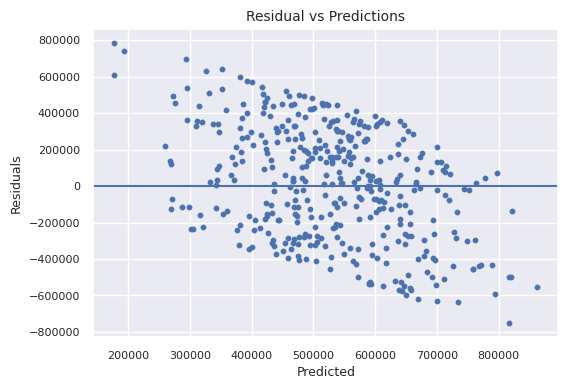

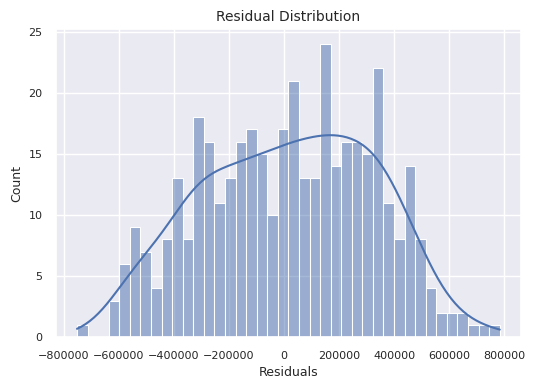

In [57]:
#residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6,4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residual vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.show()

10.Building a predictive system

In [65]:
def predict_house_price(
    model,
    house_id: int,
    area: float,
    bedrooms: int,
    bathrooms: int,
    floors: int,
    year_built: int,
    location: str,
    condition: str,
    garage: str
):
    new_row = pd.DataFrame([{
        "Id": house_id,
        "Area": area,
        "Bedrooms": bedrooms,
        "Bathrooms": bathrooms,
        "Floors": floors,
        "YearBuilt": year_built,
        "Location": location,
        "Condition": condition,
        "Garage": garage
    }])

    return model.predict(new_row)[0]

In [69]:
#Example inference

example_pred = predict_house_price(
    model=hgb_best,
    house_id=2001,
    area=2500,
    bedrooms=3,
    bathrooms=2,
    floors=2,
    year_built=2015,
    location="Downtown",
    condition="Excellent",
    garage="Yes"
)

print(f"Predicted House Price: ₹{example_pred:,.2f}")

Predicted House Price: ₹492,558.03
